In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

# Load all 30 years
files = glob.glob('../data/raw/StormEvents_details*.csv')
df = pd.concat(
    [pd.read_csv(f, low_memory=False) for f in files],
    ignore_index=True
)
print(df.shape)  # (1780730, 51)

(1780730, 51)


In [6]:
df.sample(5)

,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,...,END_RANGE,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE
1283087,201806,17,1820,201806,17,1820,125986.0,755269,WEST VIRGINIA,54.0,...,0.54,W,BUNKER HILL,38.37000,-81.74,38.37000,-81.74,"In an unstable atmosphere, showers and thunder...",Multiple trees were blown down around Dunbar.,CSV
509010,200604,8,1630,200604,8,1630,1204928.0,5491286,GEORGIA,13.0,...,NaN,NaN,HOMERVILLE,31.03333,-82.75,31.03333,-82.75,Trees were blown down in Homerville along West...,NaN,PDS
475872,200507,1,0,200507,31,2359,1194799.0,5463079,ILLINOIS,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"After a dry spring, severe drought conditions ...",NaN,PDS
264663,200106,25,1530,200106,25,1530,1118323.0,5256022,GEORGIA,13.0,...,NaN,NaN,NAOMI,34.68333,-85.20,34.68333,-85.20,NaN,A storm spotter reported dime size hail.,PDS
1748990,202502,18,0,202502,21,0,200294.0,1240718,KANSAS,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Extremely cold temperatures and wind chills im...,The ASOS at St. Joseph airport reported a mini...,CSV


In [7]:
df.describe()

,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE_FIPS,YEAR,...,CATEGORY,TOR_LENGTH,TOR_WIDTH,TOR_OTHER_CZ_FIPS,BEGIN_RANGE,END_RANGE,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON
count,1.780730e+06,1.780730e+06,1.780730e+06,1.780730e+06,1.780730e+06,1.780730e+06,1.780727e+06,1.780730e+06,1.780729e+06,1.780730e+06,...,560.000000,42778.000000,42778.000000,3736.000000,881563.000000,885468.000000,1.044626e+06,1.044619e+06,1.044626e+06,1.044619e+06
mean,2.011555e+05,1.489878e+01,1.277150e+03,2.011555e+05,1.653880e+01,1.474252e+03,5.212823e+05,2.125373e+06,3.219591e+01,2.011496e+03,...,1.551786,3.029402,160.634582,102.900161,2.873222,2.905865,3.783382e+01,-9.050529e+01,3.783251e+01,-9.049889e+01
std,8.529883e+02,9.121307e+00,6.804080e+02,8.529857e+02,9.128271e+00,6.151949e+02,6.732028e+05,2.236124e+06,1.812742e+01,8.529730e+00,...,1.015531,5.596867,266.264523,82.257866,4.852697,4.859112,5.016991e+00,1.079242e+01,5.017450e+00,1.079092e+01
min,1.996010e+05,1.000000e+00,0.000000e+00,1.996010e+05,1.000000e+00,0.000000e+00,1.000000e+00,3.000000e+00,1.000000e+00,1.996000e+03,...,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-1.440000e+01,-1.714000e+02,-1.445600e+01,-1.714000e+02
25%,2.005010e+05,7.000000e+00,8.000000e+02,2.005010e+05,9.000000e+00,1.103000e+03,7.790700e+04,4.704982e+05,1.900000e+01,2.005000e+03,...,1.000000,0.300000,30.000000,46.500000,0.690000,0.690000,3.452000e+01,-9.736640e+01,3.452000e+01,-9.736000e+01
50%,2.012020e+05,1.500000e+01,1.450000e+03,2.012020e+05,1.700000e+01,1.606000e+03,1.556470e+05,9.399315e+05,3.100000e+01,2.012000e+03,...,1.000000,1.280000,70.000000,90.000000,1.500000,1.520000,3.808333e+01,-9.031170e+01,3.808270e+01,-9.029660e+01
75%,2.019060e+05,2.300000e+01,1.803000e+03,2.019060e+05,2.500000e+01,1.910000e+03,1.121542e+06,5.277974e+06,4.600000e+01,2.019000e+03,...,2.000000,3.890000,150.000000,139.000000,3.330000,3.390000,4.133000e+01,-8.248895e+01,4.133000e+01,-8.248000e+01
max,2.025120e+05,3.100000e+01,2.359000e+03,2.025120e+05,3.100000e+01,2.359000e+03,2.414827e+06,5.725449e+06,9.900000e+01,2.025000e+03,...,5.000000,400.000000,4576.000000,820.000000,519.780000,519.780000,9.710000e+01,1.714689e+02,9.710000e+01,1.714689e+02


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1780730 entries, 0 to 1780729
Data columns (total 51 columns):
 #   Column              Dtype  
---  ------              -----  
 0   BEGIN_YEARMONTH     int64  
 1   BEGIN_DAY           int64  
 2   BEGIN_TIME          int64  
 3   END_YEARMONTH       int64  
 4   END_DAY             int64  
 5   END_TIME            int64  
 6   EPISODE_ID          float64
 7   EVENT_ID            int64  
 8   STATE               object 
 9   STATE_FIPS          float64
 10  YEAR                int64  
 11  MONTH_NAME          object 
 12  EVENT_TYPE          object 
 13  CZ_TYPE             object 
 14  CZ_FIPS             int64  
 15  CZ_NAME             object 
 16  WFO                 object 
 17  BEGIN_DATE_TIME     object 
 18  CZ_TIMEZONE         object 
 19  END_DATE_TIME       object 
 20  INJURIES_DIRECT     int64  
 21  INJURIES_INDIRECT   int64  
 22  DEATHS_DIRECT       int64  
 23  DEATHS_INDIRECT     int64  
 24  DAMAGE_PROPERTY     obje

In [9]:
df.isnull().sum()

BEGIN_YEARMONTH             0
BEGIN_DAY                   0
BEGIN_TIME                  0
END_YEARMONTH               0
END_DAY                     0
END_TIME                    0
EPISODE_ID                  3
EVENT_ID                    0
STATE                       1
STATE_FIPS                  1
YEAR                        0
MONTH_NAME                  0
EVENT_TYPE                  0
CZ_TYPE                     0
CZ_FIPS                     0
CZ_NAME                     0
WFO                         3
BEGIN_DATE_TIME             0
CZ_TIMEZONE                 0
END_DATE_TIME               0
INJURIES_DIRECT             0
INJURIES_INDIRECT           0
DEATHS_DIRECT               0
DEATHS_INDIRECT             0
DAMAGE_PROPERTY        612832
DAMAGE_CROPS           724876
SOURCE                 113596
MAGNITUDE              863277
MAGNITUDE_TYPE        1236680
FLOOD_CAUSE           1654735
CATEGORY              1780170
TOR_F_SCALE           1737951
TOR_LENGTH            1737952
TOR_WIDTH 

In [10]:
df['DAMAGE_PROPERTY'].value_counts().head(20)

DAMAGE_PROPERTY
0.00K      736046
1.00K       40019
5.00K       33347
10.00K      28189
2.00K       25060
0           20193
5K          17887
10K         14954
3.00K       14070
50.00K      11705
25.00K      11107
20.00K      10807
15.00K      10316
1K          10315
0.50K        9943
2K           9938
0K           8468
100.00K      7801
50K          6798
20K          6327
Name: count, dtype: int64

In [11]:
import re

In [12]:
def parse_damage(val):
    val = str(val).upper().strip()
    if val in ('0', '0K', '', 'NAN'): return 0.0
    m = re.match(r'([\d.]+)([KMB]?)', val)
    if not m: return 0.0
    n, s = float(m.group(1)), m.group(2)
    return n * {'K': 1e3, 'M': 1e6, 'B': 1e9}.get(s, 1)

def assign_tier(d):
    if d == 0:        return 0
    elif d < 10_000:  return 1
    elif d < 500_000: return 2
    else:             return 3

In [13]:
df['damage_num']  = df['DAMAGE_PROPERTY'].fillna('0').apply(parse_damage)
df['damage_tier'] = df['damage_num'].apply(assign_tier)
print(df['damage_tier'].value_counts())

damage_tier
0    1377653
1     205407
2     175438
3      22232
Name: count, dtype: int64


In [14]:
df['damage_crops_num'] = df['DAMAGE_CROPS'].fillna('0').apply(parse_damage)
df['damage_total_num'] = df['damage_num'] + df['damage_crops_num']

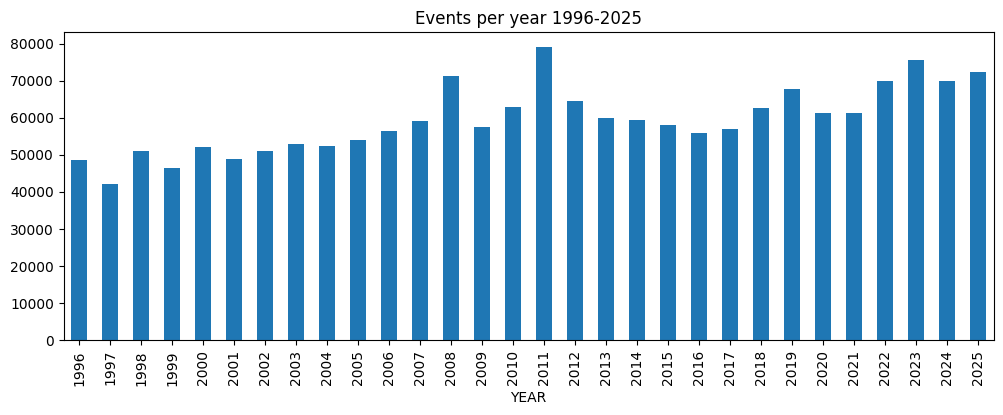

In [16]:
df['YEAR'].value_counts().sort_index().plot(kind='bar', figsize=(12,4))
plt.title('Events per year 1996-2025')
plt.show()

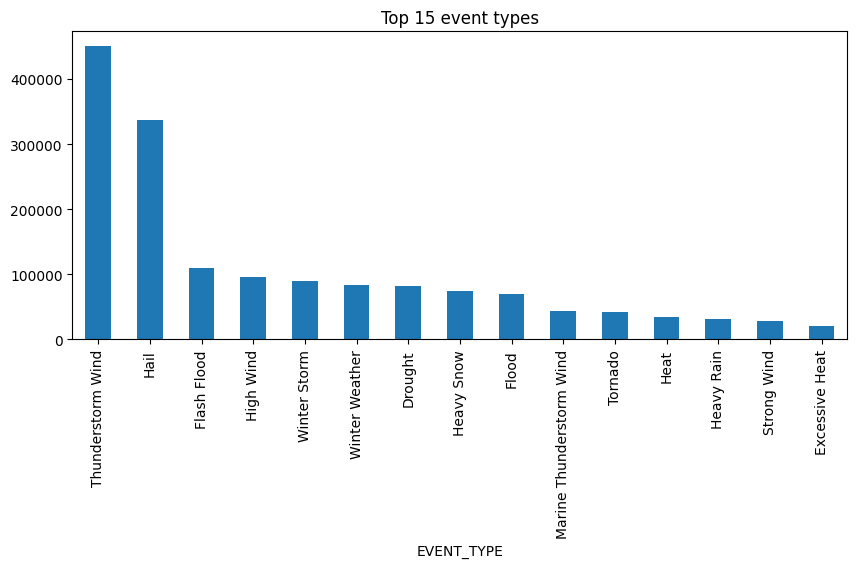

In [17]:
df['EVENT_TYPE'].value_counts().head(15).plot(kind='bar', figsize=(10,4))
plt.title('Top 15 event types')
plt.show()

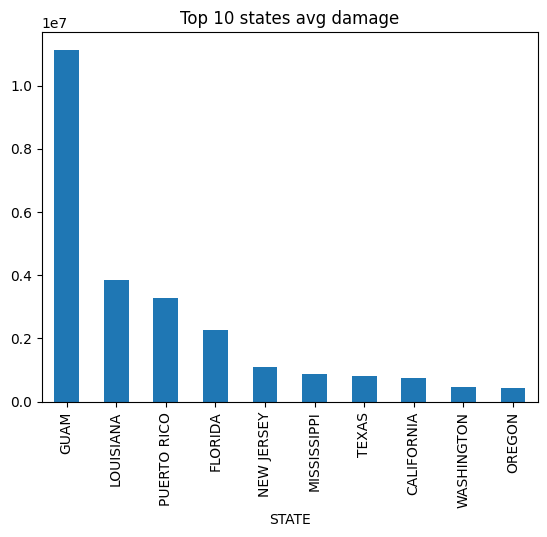

In [18]:
df.groupby('STATE')['damage_num'].mean().sort_values(
    ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 states avg damage')
plt.show()

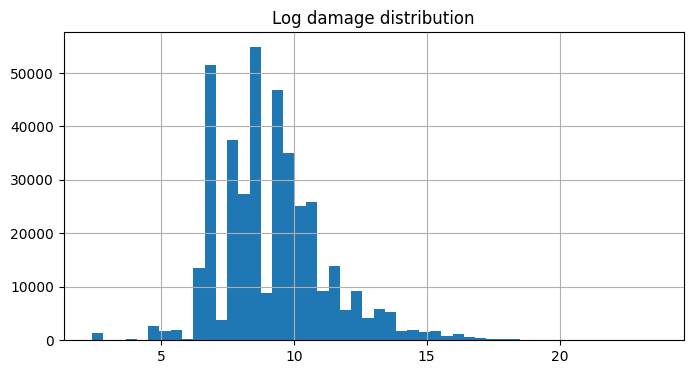

In [19]:
nonzero = df[df['damage_num'] > 0]['damage_num']
np.log1p(nonzero).hist(bins=50, figsize=(8,4))
plt.title('Log damage distribution')
plt.show()

In [20]:
df[['INJURIES_DIRECT','INJURIES_INDIRECT',
          'DEATHS_DIRECT','DEATHS_INDIRECT']].describe()

,INJURIES_DIRECT,INJURIES_INDIRECT,DEATHS_DIRECT,DEATHS_INDIRECT
count,1.780730e+06,1.780730e+06,1.780730e+06,1.780730e+06
mean,4.881257e-02,8.837387e-03,1.083207e-02,2.532108e-03
std,2.530513e+00,1.909873e+00,5.841566e-01,9.891674e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,1.150000e+03,2.400000e+03,6.380000e+02,5.600000e+01


In [21]:
test_vals = ['0.00K', '1.00K', '5.00K', '0.50K', '100.00K']
for v in test_vals:
    print(f"{v} → {parse_damage(v)}")

0.00K → 0.0
1.00K → 1000.0
5.00K → 5000.0
0.50K → 500.0
100.00K → 100000.0


In [22]:
df = df.drop(columns=['damage_num', 'damage_tier'])

In [26]:
df.to_parquet('../data/raw/storm_raw_combined.parquet', index=False)
print("saved.")
print(df.shape)

saved.
(1780730, 53)
